In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
filepath = "../data/GlobalWeatherRepository.csv"

In [2]:
df = pd.read_csv(filepath)
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
df.isna().sum().sum()

np.int64(0)

In [4]:
df.dtypes

country                          object
location_name                    object
latitude                        float64
longitude                       float64
timezone                         object
last_updated_epoch                int64
last_updated                     object
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                   object
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_index                        float64


In [5]:
drop_cols = [
    "country",
    "location_name",
    "timezone",
    "last_updated_epoch",
    "last_updated",
    "temperature_fahrenheit",
    "wind_mph",
    "wind_direction",
    "pressure_in",
    "precip_in",
    "feels_like_fahrenheit",
    "visibility_miles",
    "gust_mph",
    "sunrise",
    "sunset",
    "moonrise",
    "moonset",
    "moon_phase",
    "moon_illumination"
]

In [6]:
df_num = df.drop(columns=drop_cols)
# df_num features contain all the information from df
df_num.dtypes

latitude                        float64
longitude                       float64
temperature_celsius             float64
condition_text                   object
wind_kph                        float64
wind_degree                       int64
pressure_mb                     float64
precip_mm                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
visibility_km                   float64
uv_index                        float64
gust_kph                        float64
air_quality_Carbon_Monoxide     float64
air_quality_Ozone               float64
air_quality_Nitrogen_dioxide    float64
air_quality_Sulphur_dioxide     float64
air_quality_PM2.5               float64
air_quality_PM10                float64
air_quality_us-epa-index          int64
air_quality_gb-defra-index        int64
dtype: object

In [7]:
print(len(df))
print(len(df["condition_text"].unique()))
df["condition_text"].unique()

164499
57


array(['Partly Cloudy', 'Partly cloudy', 'Sunny', 'Light drizzle',
       'Clear', 'Overcast', 'Moderate or heavy rain with thunder',
       'Patchy light rain in area with thunder', 'Fog',
       'Patchy light rain with thunder', 'Patchy rain nearby',
       'Light rain', 'Mist', 'Cloudy', 'Thundery outbreaks in nearby',
       'Moderate rain', 'Light rain shower', 'Moderate rain at times',
       'Moderate or heavy rain shower', 'Heavy rain at times',
       'Patchy light rain', 'Patchy light drizzle',
       'Thundery outbreaks possible', 'Patchy rain possible',
       'Moderate or heavy rain in area with thunder', 'Heavy rain',
       'Torrential rain shower', 'Freezing fog',
       'Moderate or heavy snow showers', 'Light sleet', 'Blizzard',
       'Moderate snow', 'Light snow', 'Light sleet showers',
       'Light freezing rain', 'Heavy snow', 'Blowing snow',
       'Patchy heavy snow', 'Light snow showers',
       'Moderate or heavy sleet', 'Patchy light snow',
       'Patchy mo

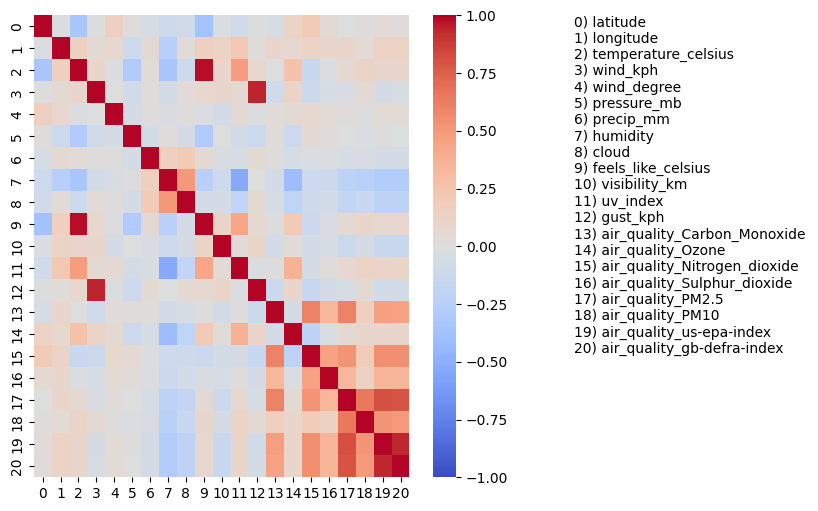

In [8]:
trunc_df = df_num.drop(columns=["condition_text"])
corr_matrix = np.corrcoef(trunc_df.to_numpy().T)  # rows should be features

fig, axes = plt.subplots(1, 2, figsize=(10, 6), gridspec_kw={'width_ratios': [2, 1]})

sns.heatmap(    
    corr_matrix, 
    ax=axes[0],
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,
)

en_cols = list(enumerate(trunc_df.columns))
named_cols = [f"{i}) {name}" for i, name in en_cols]

axes[1].axis("off")
axes[1].text(
    0., 1.,
    "\n".join(named_cols),
    ha='left', va='top',
    fontsize=10,
    transform=axes[1].transAxes
)

plt.show()

### Strong linear correllations:
 - temperature - apparent temperature
 - wind speed - gust speed
 - humidity - uv index (negative)
 - temperature - uv index
 - air quality metrics
### Weaker:
 - temperature - latitude
 - apparent temperature - humidity, pressure

<Axes: xlabel='temperature_celsius', ylabel='Count'>

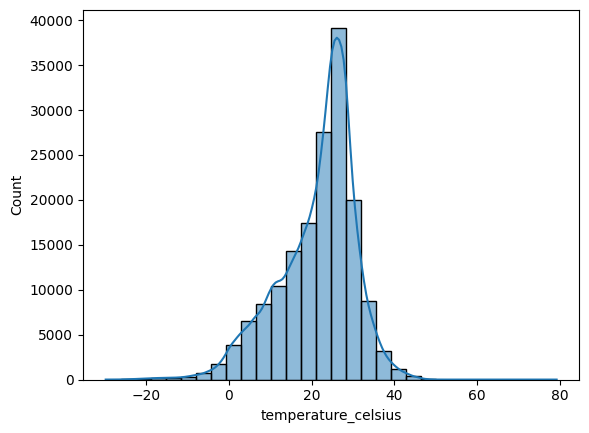

In [9]:
sns.histplot(df['temperature_celsius'], kde=True, bins=30)

<Axes: xlabel='precip_mm', ylabel='Count'>

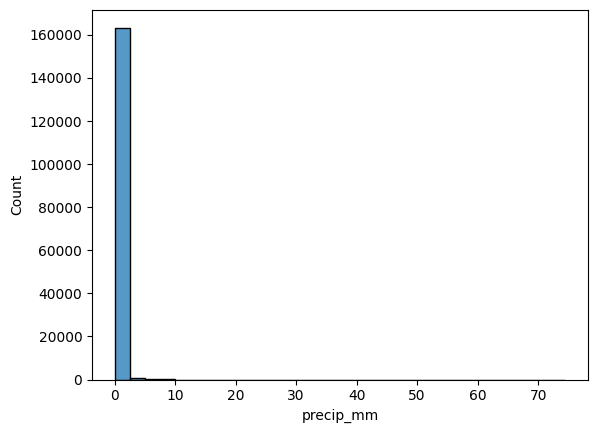

In [10]:
sns.histplot(df['precip_mm'], bins=30)

In [11]:
humid_avgs = df.groupby("condition_text")["precip_mm"].mean().sort_values()
humid_avgs

condition_text
Blowing dust                                   0.000000
Dust haze                                      0.000000
Dust storm                                     0.000000
Haze                                           0.000000
Sandstorm                                      0.000000
Severe sandstorm                               0.000000
Smog                                           0.000000
Partly Cloudy                                  0.000000
Smoky haze                                     0.000000
Sunny                                          0.001780
Freezing fog                                   0.004073
Clear                                          0.005510
Cloudy                                         0.007325
Fog                                            0.019835
Thundery outbreaks in nearby                   0.025542
Mist                                           0.031782
Freezing drizzle                               0.044000
Patchy snow nearby               

In [12]:
df['last_updated'] = pd.to_datetime(df['last_updated'])
df = df.set_index('last_updated').sort_index()

df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df['year'] = df.index.year

In [13]:
df["country"].value_counts().head(15)

country
Bulgaria       1941
Indonesia      1692
Thailand       1689
Turkey         1685
Sudan          1685
Bolivia        1678
Iran           1645
Belgium        1594
Madagascar     1303
Vietnam        1299
Hungary         980
Senegal         944
Russia          899
Switzerland     895
Norway          872
Name: count, dtype: int64

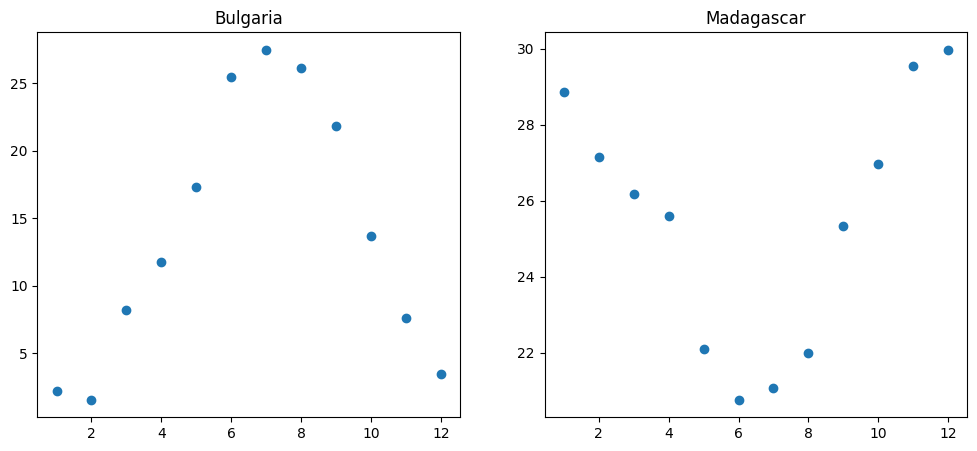

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bulg_avgs = df[df["country"] == "Bulgaria"].groupby("month")["temperature_celsius"].mean()
axes[0].scatter(bulg_avgs.index, bulg_avgs.values)
axes[0].set_title("Bulgaria")

mad_avgs = df[df["country"] == "Madagascar"].groupby("month")["temperature_celsius"].mean()
axes[1].scatter(mad_avgs.index, mad_avgs.values)
axes[1].set_title("Madagascar")

plt.show()

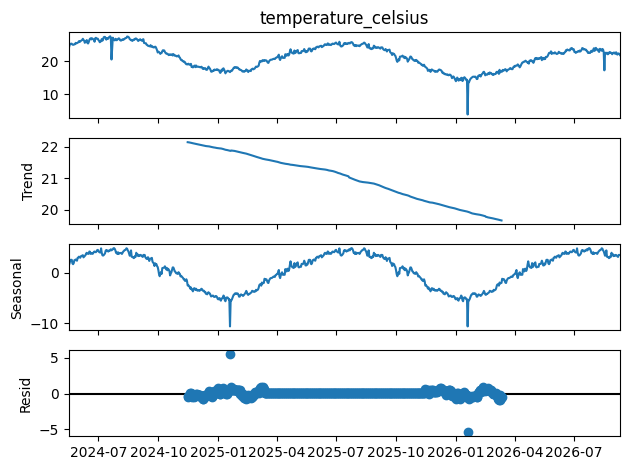

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df['temperature_celsius'].resample('D').mean().dropna(),
    model='additive', period=365
    )
decomposition.plot()
plt.show()

In [23]:
residuals = decomposition.resid.dropna()

resid_std = residuals.std()
resid_mean = residuals.mean()

anomalies = residuals[np.abs(residuals - resid_mean) > 3 * resid_std]
anomalies  # outliers

last_updated
2025-01-19    5.512834
2026-01-19   -5.414774
Name: resid, dtype: float64